# MGFR Attribute Classifier — Fine-tune ResNet-50 on CelebA
Fine-tunes an ImageNet ResNet-50 on CelebA 40-attribute classification.
Follows He et al. 2017 / MGFR paper setup: 28 binary sigmoid heads, BCE loss.
Expected: ~90% mean accuracy after 1 epoch (~1.5 hrs on Kaggle P100).

In [4]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'kagglehub', 'torch', 'torchvision', 'numpy',
                'matplotlib', 'Pillow', 'scikit-learn', 'pandas', 'tqdm'],
               check=True)

import os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import kagglehub

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device  : cuda
PyTorch : 2.9.0+cu126
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB


## Config — edit these if needed

In [6]:
# ── Training hyperparameters ─────────────────────────────────────────────
NUM_EPOCHS    = 2     # 1 epoch is enough (~90% acc); set 2 for ~91%
BATCH_SIZE    = 64      # reduce to 32 if OOM
LR            = 1e-4    # learning rate for attribute heads
LR_BACKBONE   = 1e-5    # lower LR for backbone (fine-tuning, not training from scratch)
NUM_WORKERS   = 4
IMG_SIZE      = 224
SAVE_PATH     = 'celeba_resnet50_finetuned_new.pth'

# ── Which attributes to train ─────────────────────────────────────────────
# 'all40' → train all 40 CelebA attributes (then slice to 28 at inference)
# 'paper28' → train only the 28 attributes used in the MGFR paper
ATTR_MODE = 'all40'   # recommended: all40 keeps full CelebA compatibility

print('Config set.')

Config set.


## Download CelebA from Kaggle

In [7]:
path = kagglehub.dataset_download('jessicali9530/celeba-dataset')
print(f'Dataset root: {path}')

# Locate image folder
IMG_DIR = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'
# for root, dirs, files in os.walk(path):
#     if os.path.basename(root) == 'img_align_celeba' and files:
#         IMG_DIR = root
#         break
#     if 'img_align_celeba' in dirs:
#         IMG_DIR = os.path.join(root, 'img_align_celeba')
#         break

# Locate attribute CSV
LABEL_FILE = '/kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv'
# for root, dirs, files in os.walk(path):
#     for f in files:
#         if 'attr' in f.lower() and (f.endswith('.csv') or f.endswith('.txt')):
#             LABEL_FILE = os.path.join(root, f)
#             break

assert IMG_DIR,    f'img_align_celeba not found under {path}'
assert LABEL_FILE, f'Attribute label file not found under {path}'
print(f'Images : {IMG_DIR}')
print(f'Labels : {LABEL_FILE}')
print(f'N imgs : {len(os.listdir(IMG_DIR))}')

Dataset root: /kaggle/input/datasets/jessicali9530/celeba-dataset
Images : /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
Labels : /kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv
N imgs : 202599


## Parse labels

In [8]:
df = pd.read_csv(LABEL_FILE)
print(f'CSV shape : {df.shape}')
print(f'Columns   : {list(df.columns[:6])} ...')

# First column = filename, rest = 40 attributes
FILENAME_COL = df.columns[0]
ATTR_COLS    = list(df.columns[1:])
assert len(ATTR_COLS) == 40, f'Expected 40 attr columns, got {len(ATTR_COLS)}'

# Convert 1/-1 → 1/0
df[ATTR_COLS] = (df[ATTR_COLS] == 1).astype(np.float32)

# Official CelebA split indices
N_TRAIN = 162770
N_VAL   = 19867
N_TEST  = 19962
df_train = df.iloc[:N_TRAIN].reset_index(drop=True)
df_val   = df.iloc[N_TRAIN:N_TRAIN+N_VAL].reset_index(drop=True)
df_test  = df.iloc[N_TRAIN+N_VAL:].reset_index(drop=True)

print(f'Train : {len(df_train)}')
print(f'Val   : {len(df_val)}')
print(f'Test  : {len(df_test)}')

# If paper28 mode, select only the 28 attribute columns
CELEBA_40 = ATTR_COLS   # preserve original 40-attr order

PAPER_28_TO_CELEBA40 = {
    'Black Hair': 'Black_Hair', 'Blond Hair': 'Blond_Hair',
    'Blurry': 'Blurry', 'Brown Hair': 'Brown_Hair',
    'Eyeglasses': 'Eyeglasses', 'Gray Hair': 'Gray_Hair',
    'Heavy Makeup': 'Heavy_Makeup', 'Mouth Slightly Open': 'Mouth_Slightly_Open',
    'Mustache': 'Mustache', 'Big Eyes': 'Narrow_Eyes',
    'No Beard': 'No_Beard', 'Receding Hairline': 'Receding_Hairline',
    'Sideburns': 'Sideburns', 'Smiling': 'Smiling',
    'Straight Hair': 'Straight_Hair', 'Wearing Earrings': 'Wearing_Earrings',
    'Wearing Hat': 'Wearing_Hat', 'Male': 'Male',
    'Wearing Necklace': 'Wearing_Necklace', 'Big Nose': 'Big_Nose',
    'Wearing Lipstick': 'Wearing_Lipstick', 'Young': 'Young',
    'Wavy Hair': 'Wavy_Hair', 'Big Lips': 'Big_Lips',
    'Bald': 'Bald', 'Bangs': 'Bangs',
    'Chubby': 'Chubby', 'Double Chin': 'Double_Chin',
}
PAPER_28    = list(PAPER_28_TO_CELEBA40.keys())
CELEBA40_IDX = {name: i for i, name in enumerate(CELEBA_40)}
ATTR_28_INDICES = [CELEBA40_IDX[PAPER_28_TO_CELEBA40[a]] for a in PAPER_28]
INVERTED_IDX    = [i for i, a in enumerate(PAPER_28) if a == 'Big Eyes']

if ATTR_MODE == 'paper28':
    TRAIN_COLS = [CELEBA_40[i] for i in ATTR_28_INDICES]
    # Flip Narrow_Eyes -> Big Eyes in the labels
    for split in [df_train, df_val, df_test]:
        split['Narrow_Eyes'] = 1.0 - split['Narrow_Eyes']
    print(f'Training on 28 attributes')
else:
    TRAIN_COLS = CELEBA_40
    print(f'Training on all 40 attributes')

NUM_ATTRS = len(TRAIN_COLS)
print(f'NUM_ATTRS = {NUM_ATTRS}')

CSV shape : (202599, 41)
Columns   : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald'] ...
Train : 162770
Val   : 19867
Test  : 19962
Training on all 40 attributes
NUM_ATTRS = 40


## Dataset class

In [9]:
class CelebADataset(Dataset):
    def __init__(self, df, img_dir, attr_cols, transform):
        self.df        = df
        self.img_dir   = img_dir
        self.attr_cols = attr_cols
        self.transform = transform
        self.fname_col = df.columns[0]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row[self.fname_col])
        img      = Image.open(img_path).convert('RGB')
        img      = self.transform(img)
        labels   = torch.tensor(row[self.attr_cols].values.astype(np.float32))
        return img, labels


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

train_ds = CelebADataset(df_train, IMG_DIR, TRAIN_COLS, train_transform)
val_ds   = CelebADataset(df_val,   IMG_DIR, TRAIN_COLS, val_transform)
test_ds  = CelebADataset(df_test,  IMG_DIR, TRAIN_COLS, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Sanity: load one batch
imgs, labels = next(iter(train_loader))
print(f'Batch shape   : {imgs.shape}  labels: {labels.shape}')

Train batches : 2544
Val   batches : 311
Test  batches : 312
Batch shape   : torch.Size([64, 3, 224, 224])  labels: torch.Size([64, 40])


## Build model — ResNet-50 backbone + attribute heads

In [10]:
def build_model(num_attrs, device, pretrained=True):
    """
    ResNet-50 with ImageNet weights, FC replaced by num_attrs binary heads.
    Returns model + two param groups (backbone / head) for differential LR.
    """
    weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
    model   = models.resnet50(weights=weights)
    in_feat = model.fc.in_features           # 2048
    model.fc = nn.Linear(in_feat, num_attrs) # replace 1000-class head
    model.to(device)

    backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
    head_params     = list(model.fc.parameters())
    return model, backbone_params, head_params


model, backbone_params, head_params = build_model(NUM_ATTRS, DEVICE)

# Differential learning rates: backbone gets 10x lower LR
optimizer = optim.Adam([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR},
], weight_decay=1e-4)

# Cosine LR schedule over 1 epoch
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=len(train_loader)
)

# Binary cross-entropy: each attribute is an independent sigmoid
criterion = nn.BCEWithLogitsLoss()

total_params = sum(p.numel() for p in model.parameters())
print(f'Total params  : {total_params/1e6:.1f}M')
print(f'FC head       : {NUM_ATTRS} outputs')
print(f'Optimizer     : Adam  backbone_lr={LR_BACKBONE}  head_lr={LR}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


Total params  : 23.6M
FC head       : 40 outputs
Optimizer     : Adam  backbone_lr=1e-05  head_lr=0.0001


## Evaluation helper

In [11]:
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_gt = [], []

    with torch.no_grad():
        for i, (imgs, labels) in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            preds  = (torch.sigmoid(logits) >= 0.5).float()

            total_loss    += loss.item() * imgs.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += imgs.size(0) * labels.size(1)
            all_preds.append(preds.cpu())
            all_gt.append(labels.cpu())

    avg_loss = total_loss / (total_samples / labels.size(1))
    avg_acc  = total_correct / total_samples

    all_preds = torch.cat(all_preds).numpy()
    all_gt    = torch.cat(all_gt).numpy()
    per_attr_acc = (all_preds == all_gt).mean(axis=0)

    return avg_loss, avg_acc, per_attr_acc


print('Eval function defined.')

Eval function defined.


## Train!
1 epoch on 162,770 images takes ~80–100 mins on a Kaggle P100.  
Val accuracy is checked every 5,000 steps so you can monitor progress.

In [12]:
EVAL_EVERY   = 5000   # steps between quick val checks
LOG_EVERY    = 200    # steps between loss prints

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'step': []}
best_val_acc = 0.0
step = 0
t0   = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        step += 1

        if step % LOG_EVERY == 0:
            avg = running_loss / LOG_EVERY
            pbar.set_postfix({'loss': f'{avg:.4f}'})
            running_loss = 0.0

        if step % EVAL_EVERY == 0:
            val_loss, val_acc, _ = evaluate(model, val_loader, criterion, DEVICE, max_batches=50)
            elapsed = (time.time() - t0) / 60
            print(f'  step {step:6d} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | {elapsed:.1f}min')
            history['step'].append(step)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), SAVE_PATH)
                print(f'  ✓ Saved best model (val_acc={val_acc:.4f})')
            model.train()

    # Save at end of each epoch regardless
    torch.save(model.state_dict(), SAVE_PATH)
    elapsed = (time.time() - t0) / 60
    print(f'\nEpoch {epoch+1} done in {elapsed:.1f} min — model saved to {SAVE_PATH}')

Epoch 1/2:   0%|          | 0/2544 [00:00<?, ?it/s]


Epoch 1 done in 13.0 min — model saved to celeba_resnet50_finetuned_new.pth


Epoch 2/2:   0%|          | 0/2544 [00:00<?, ?it/s]

  step   5000 | val_loss=0.2048 | val_acc=0.9111 | 25.7min
  ✓ Saved best model (val_acc=0.9111)

Epoch 2 done in 26.1 min — model saved to celeba_resnet50_finetuned_new.pth


## Full evaluation on test set

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc, per_attr_acc = evaluate(model, test_loader, criterion, DEVICE)

print(f'Test loss : {test_loss:.4f}')
print(f'Test acc  : {test_acc*100:.2f}%')
print()

# Per-attribute breakdown
attr_results = sorted(zip(TRAIN_COLS, per_attr_acc), key=lambda x: x[1])
print(f'  {"ATTRIBUTE":<30} {"ACC":>6}')
print('  ' + '-'*38)
for attr, acc in attr_results:
    flag = '  <-- LOW' if acc < 0.80 else ''
    print(f'  {attr:<30} {acc*100:5.1f}%{flag}')
print()
print(f'  Mean accuracy : {per_attr_acc.mean()*100:.2f}%')
print(f'  Min accuracy  : {per_attr_acc.min()*100:.2f}%  ({TRAIN_COLS[per_attr_acc.argmin()]})')
print(f'  Max accuracy  : {per_attr_acc.max()*100:.2f}%  ({TRAIN_COLS[per_attr_acc.argmax()]})')

Test loss : 0.2108
Test acc  : 90.57%

  ATTRIBUTE                         ACC
  --------------------------------------
  Big_Lips                        70.4%  <-- LOW
  Oval_Face                       74.0%  <-- LOW
  Pointy_Nose                     75.6%  <-- LOW
  Arched_Eyebrows                 82.2%
  Attractive                      82.3%
  Wavy_Hair                       82.5%
  Big_Nose                        83.5%
  Straight_Hair                   83.6%
  Bags_Under_Eyes                 83.8%
  Wearing_Necklace                86.3%
  High_Cheekbones                 87.0%
  Narrow_Eyes                     87.0%
  Young                           87.4%
  Brown_Hair                      88.6%
  Black_Hair                      88.9%
  Wearing_Earrings                89.5%
  Heavy_Makeup                    91.3%
  Smiling                         91.3%
  Bushy_Eyebrows                  91.6%
  Receding_Hairline               92.9%
  Wearing_Lipstick                92.9%
  Mouth_Sligh

## Training curve

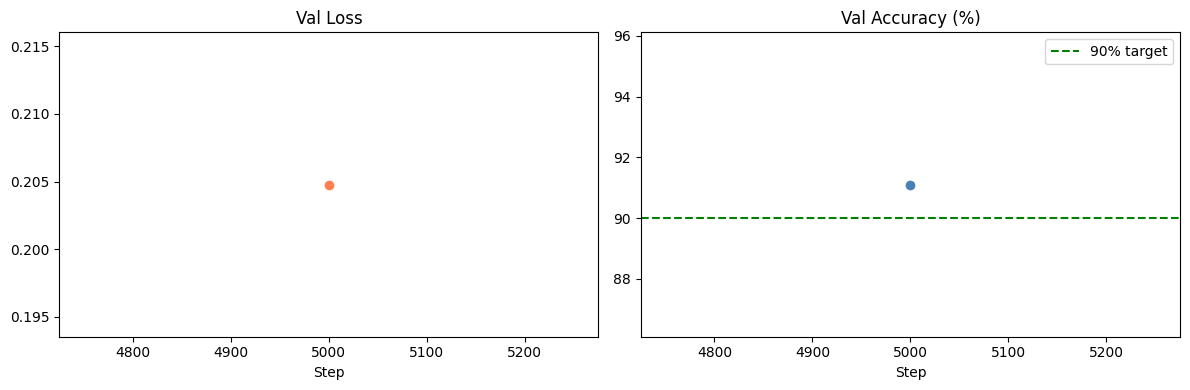

In [14]:
if history['step']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['step'], history['val_loss'], 'o-', color='coral')
    axes[0].set_title('Val Loss'); axes[0].set_xlabel('Step')
    axes[1].plot(history['step'], [a*100 for a in history['val_acc']], 'o-', color='steelblue')
    axes[1].axhline(90, color='green', linestyle='--', label='90% target')
    axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('Step')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('training_curve.png', dpi=150)
    plt.show()
else:
    print('No checkpoints recorded (training completed in < EVAL_EVERY steps)')

### Test and Val performance

In [15]:
# Full train + val evaluation on saved checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

print("Evaluating on train set (this takes ~5 min)...")
train_loss, train_acc, train_per_attr = evaluate(model, train_loader, criterion, DEVICE)

print("Evaluating on val set...")
val_loss, val_acc, val_per_attr = evaluate(model, val_loader, criterion, DEVICE)

print(f'\n{"Split":<8} {"Loss":>8} {"Mean Acc":>10} {"Min Acc":>10} {"Max Acc":>10}')
print('-' * 50)
print(f'{"Train":<8} {train_loss:>8.4f} {train_acc*100:>9.2f}% '
      f'{train_per_attr.min()*100:>9.2f}% {train_per_attr.max()*100:>9.2f}%')
print(f'{"Val":<8} {val_loss:>8.4f} {val_acc*100:>9.2f}% '
      f'{val_per_attr.min()*100:>9.2f}% {val_per_attr.max()*100:>9.2f}%')

# Check for overfitting
gap = train_acc - val_acc
if gap > 0.03:
    print(f'\n⚠ Train/val gap = {gap*100:.1f}% — some overfitting, consider adding dropout')
elif gap < 0:
    print(f'\n✓ Val slightly higher than train (good regularisation from augmentation)')
else:
    print(f'\n✓ Train/val gap = {gap*100:.1f}% — no significant overfitting')

Evaluating on train set (this takes ~5 min)...
Evaluating on val set...

Split        Loss   Mean Acc    Min Acc    Max Acc
--------------------------------------------------
Train      0.1951     91.43%     76.12%     99.55%
Val        0.2014     91.18%     73.76%     99.43%

✓ Train/val gap = 0.3% — no significant overfitting


## Per-attribute accuracy bar chart

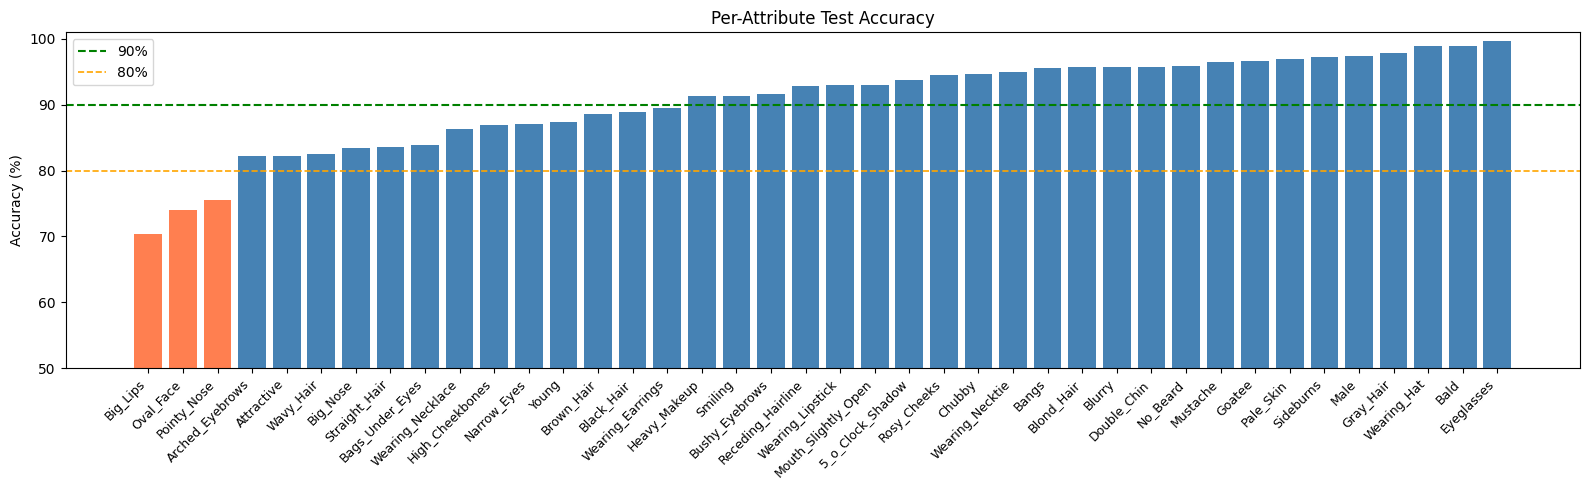

In [16]:
attrs_sorted = [a for a, _ in attr_results]
accs_sorted  = [a for _, a in attr_results]

colors = ['coral' if a < 0.80 else 'steelblue' for a in accs_sorted]
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(attrs_sorted)), [a*100 for a in accs_sorted], color=colors)
ax.axhline(90, color='green', linestyle='--', linewidth=1.5, label='90%')
ax.axhline(80, color='orange', linestyle='--', linewidth=1.2, label='80%')
ax.set_xticks(range(len(attrs_sorted)))
ax.set_xticklabels(attrs_sorted, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(50, 101)
ax.set_title('Per-Attribute Test Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('per_attr_accuracy.png', dpi=150)
plt.show()

## Save weights for use in mgfr_prompt_generator.py
Download `celeba_resnet50_finetuned.pth` from the Kaggle output panel
and use it as `--weights` in `mgfr_prompt_generator.py`.

In [17]:
# Confirm file size
size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Saved : {SAVE_PATH}  ({size_mb:.1f} MB)')
print()
print('Next steps:')
print('  1. Download celeba_resnet50_finetuned.pth from Kaggle output')
print('  2. Use as --weights in mgfr_prompt_generator.py')
print('  3. Set NUM_ATTRS in prompt generator to match ATTR_MODE:')
if ATTR_MODE == 'all40':
    print('     ATTR_MODE=all40 → model outputs 40, sliced to 28 at inference')
    print('     In mgfr_prompt_generator.py: the ATTR_28_INDICES slice handles this')
else:
    print('     ATTR_MODE=paper28 → model outputs 28 directly')

Saved : celeba_resnet50_finetuned_new.pth  (94.7 MB)

Next steps:
  1. Download celeba_resnet50_finetuned.pth from Kaggle output
  2. Use as --weights in mgfr_prompt_generator.py
  3. Set NUM_ATTRS in prompt generator to match ATTR_MODE:
     ATTR_MODE=all40 → model outputs 40, sliced to 28 at inference
     In mgfr_prompt_generator.py: the ATTR_28_INDICES slice handles this
